## Single cell analysis with scanpy!

We will analysize single cell transcriptomic datasets derived from Peripheral Blood Mononuclear Cells (PBMC) cells from a healthy donor. This notebook is adapted from a [scanpy tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html) availble on the official [scanpy page](https://scanpy.readthedocs.io/en/stable/)

### 1. Load and preprocess your data

*Load* your dataset in the notebook and preprocess it as we discussed during the lesson:

- Quality control and filtering
- Normalization and log-transformation
- Identification of highly variable genes and PCA
- Clustering and visualization

Each decision you make in the analysis should be appropriately documented

In [ ]:
%pip install anndata
%pip install igraph
%pip install ipywidgets widgetsnbextension
%pip install scanpy
%matplotlib inline

In [ ]:
%pip install scanpy
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
%matplotlib inline

Load and check dataset

In [ ]:
data = sc.read_h5ad('/content/adata_group2.h5ad')

In [ ]:
data

AnnData object with n_obs × n_vars = 820 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [ ]:
data.obs

""
AAACATTGAGCTAC-1
AAACCGTGTATGCG-1
AAACGCTGGTTCTT-1
AAACGCTGTAGCCA-1
AAACTTGAAAAACG-1
...
TTTCAGTGTCACGA-1
TTTCAGTGTGCAGT-1
TTTCTACTGAGGCA-1
TTTCTACTTCCTCG-1


In [ ]:
data.var

,gene_ids
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180
AC002321.2,ENSG00000215616


In [ ]:
print(data.X[25:49, 25:49].todense())

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  2.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  2.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.
   0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.
   0.  0.  0.  1.

In [ ]:
print(data.X)

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 656114 stored elements and shape (820, 32738)>
  Coords	Values
  (527, 5)	1.0
  (772, 8)	1.0
  (567, 22)	1.0
  (685, 22)	1.0
  (137, 26)	1.0
  (387, 26)	1.0
  (468, 26)	1.0
  (738, 26)	1.0
  (793, 26)	1.0
  (800, 26)	1.0
  (785, 27)	1.0
  (599, 33)	1.0
  (8, 35)	1.0
  (12, 35)	1.0
  (15, 35)	1.0
  (16, 35)	1.0
  (32, 35)	1.0
  (35, 35)	1.0
  (44, 35)	1.0
  (46, 35)	1.0
  (52, 35)	2.0
  (54, 35)	2.0
  (62, 35)	1.0
  (68, 35)	1.0
  (76, 35)	1.0
  :	:
  (662, 32731)	1.0
  (671, 32731)	1.0
  (733, 32731)	1.0
  (761, 32731)	1.0
  (767, 32731)	2.0
  (777, 32731)	1.0
  (805, 32731)	1.0
  (13, 32732)	1.0
  (32, 32732)	1.0
  (91, 32732)	1.0
  (98, 32732)	1.0
  (197, 32732)	1.0
  (246, 32732)	1.0
  (266, 32732)	1.0
  (325, 32732)	1.0
  (416, 32732)	1.0
  (467, 32732)	1.0
  (483, 32732)	1.0
  (500, 32732)	1.0
  (504, 32732)	1.0
  (511, 32732)	1.0
  (722, 32732)	2.0
  (725, 32732)	1.0
  (734, 32732)	1.0
  (803, 32732)	1.0


In [ ]:
print(data.X[data.X != 0].mean())
print(data.X.max())

2.525968
229.0


We are typically capturing a low number of transcripts per gene per cell

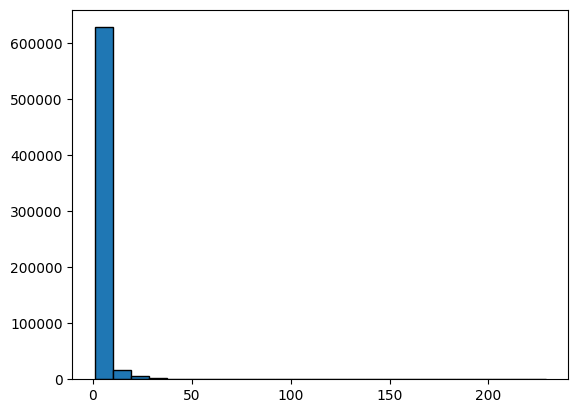

In [ ]:
tmp = plt.hist(data.X.data, bins=25, edgecolor='black')

The few highly expressed genes 'squash' all the other genes into one tiny bar. By taking the log, we spread out those low values so we can actually see the distribution of the majority of our data.

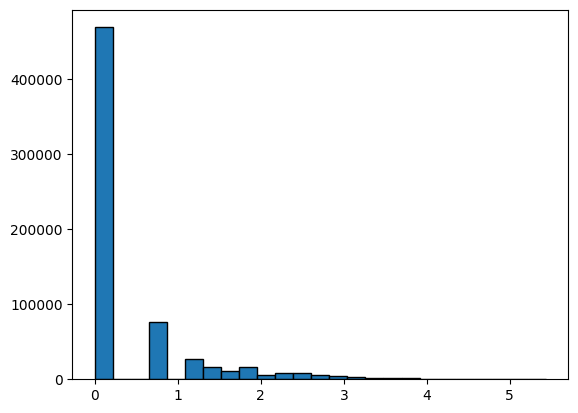

In [ ]:
tmp = plt.hist(np.log(data.X.data), bins=25, edgecolor='black')

There is not a specific number to set in min_genes and min_cells. However, there are some recomendations.

1. min_genes (per cell): Usually between 200 and 500.

- - Low (100-200): Used for 'difficult' samples or nuclei sequencing (snRNA-seq) where you expect less RNA.
- - High (500+): Used for high-quality datasets to ensure only very robust cells remain.

2. min_cells (per gene): Usually 3, 5, or 10.

In [ ]:
sc.pp.filter_cells(data, min_genes=100) # Filtering cells with less than 100 genes expressed
sc.pp.filter_genes(data, min_cells=3) # Filtering genes expressed in less than 3 cells
data.shape

(820, 11074)

### 2. Quality control and filtering

High Mitochondrial content (e.g., >5% or >10%) might be a problem. We need to detect dying cells

In [ ]:
data.var["mt"] = data.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(data, qc_vars=["mt"], inplace=True, log1p=False)

In [ ]:
data.var

,gene_ids,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
LINC00115,ENSG00000225880,6,False,6,0.007317,99.268293,6.0
NOC2L,ENSG00000188976,90,False,90,0.119512,89.024390,98.0
HES4,ENSG00000188290,6,False,6,0.007317,99.268293,6.0
ISG15,ENSG00000187608,290,False,290,0.631707,64.634146,518.0
C1orf159,ENSG00000131591,6,False,6,0.007317,99.268293,6.0
...,...,...,...,...,...,...,...
MT-CYB,ENSG00000198727,761,True,761,3.957317,7.195122,3245.0
AC145212.1,ENSG00000215750,3,False,3,0.003659,99.634146,3.0
AL592183.1,ENSG00000220023,105,False,105,0.147561,87.195122,121.0
PNRC2-1,ENSG00000215700,31,False,31,0.040244,96.219512,33.0


In [ ]:
data.obs

,n_genes,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt
AAACATTGAGCTAC-1,1352,1344,4876.0,45.754717,61.177194,71.882691,82.690730,186.0,3.814602
AAACCGTGTATGCG-1,522,519,978.0,44.989775,55.828221,67.382413,98.057260,12.0,1.226994
AAACGCTGGTTCTT-1,790,787,2257.0,46.787771,61.896323,72.972973,87.284005,70.0,3.101462
AAACGCTGTAGCCA-1,533,530,1273.0,51.060487,63.000786,74.076984,97.643362,15.0,1.178319
AAACTTGAAAAACG-1,1116,1109,3911.0,44.080798,60.905139,72.692406,84.428535,103.0,2.633598
...,...,...,...,...,...,...,...,...,...
TTTCAGTGTCACGA-1,700,698,1632.0,39.828431,55.882353,69.485294,87.867647,56.0,3.431373
TTTCAGTGTGCAGT-1,637,633,1318.0,39.908953,53.945372,67.147193,89.908953,25.0,1.896813
TTTCTACTGAGGCA-1,1227,1216,3435.0,37.409025,52.081514,64.104803,79.155750,32.0,0.931587
TTTCTACTTCCTCG-1,622,620,1682.0,45.838288,61.712247,75.029727,92.865636,37.0,2.199762


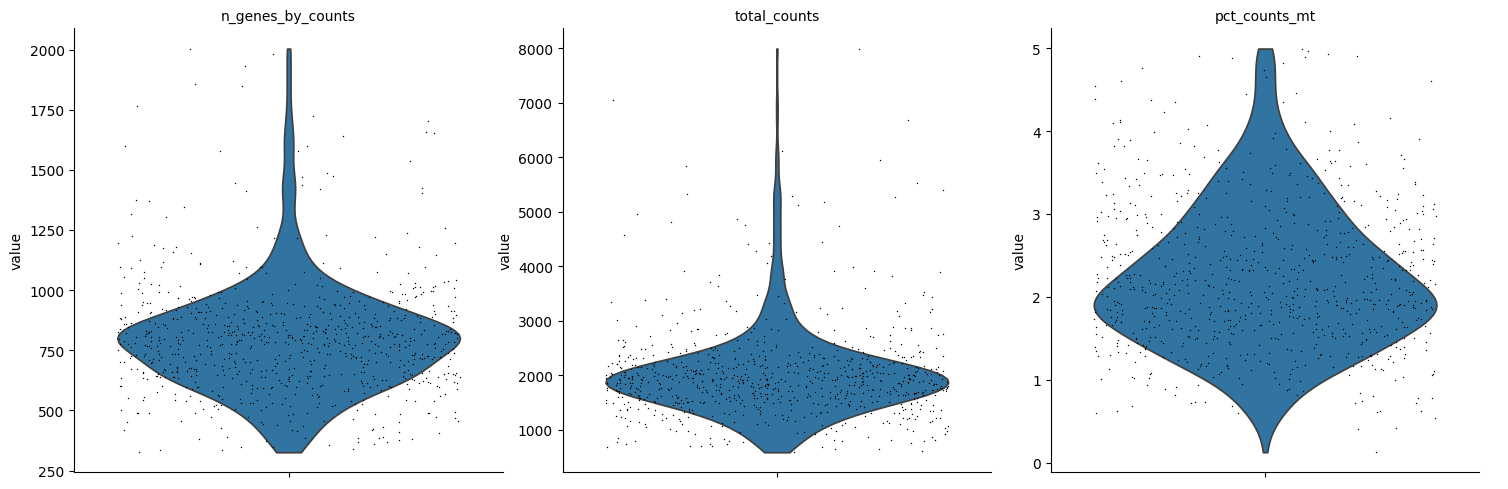

In [ ]:
sc.pl.violin(
    data,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

**total_counts:** The total number of RNA molecules (transcripts) detected in a cell.

**n_genes_by_counts:** The number of unique genes that had at least one count in that cell.

**pct_counts_mt:** The fraction of your total_counts that come from mitochondrial genes.

We keep the cells with only 4% of mithocondrial RNA and remove the cells with more than 3000 counts (doublets).

In [ ]:
data = data[data.obs.pct_counts_mt < 4, :]
data_t = data[data.obs.total_counts < 3000, :]

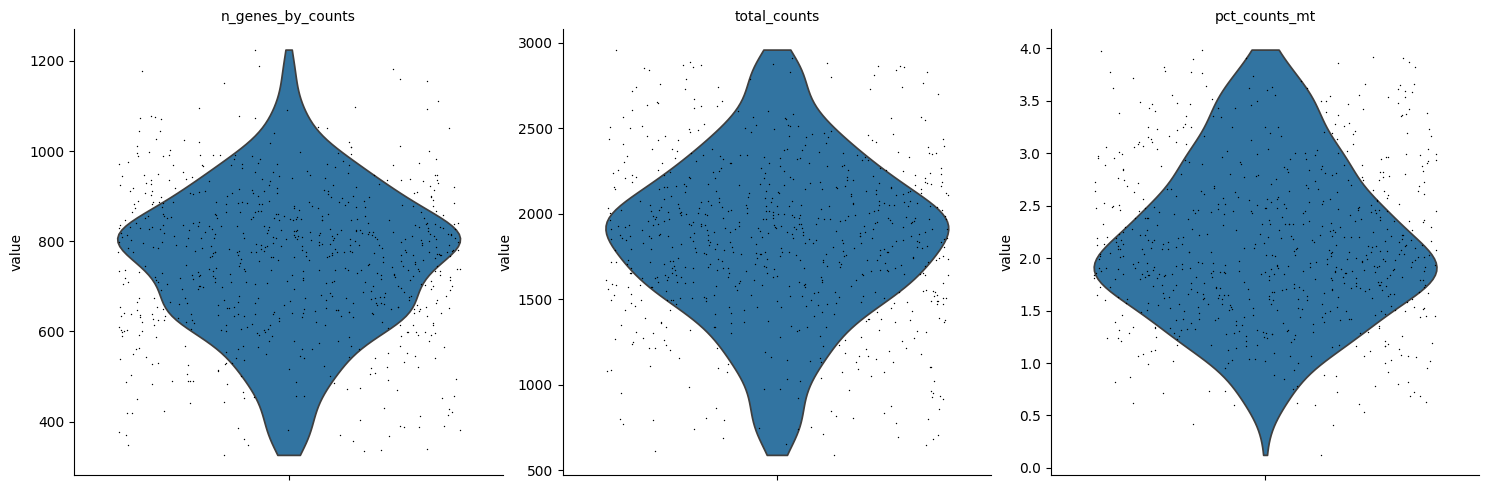

In [ ]:
sc.pl.violin(
    data_t,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
data_t.shape

(727, 11074)

In [ ]:
data = data_t

Normalization


In [ ]:
# Saving count data
data.layers["counts"] = data.X.copy()

/tmp/ipykernel_1985/4247022558.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  data.layers["counts"] = data.X.copy()


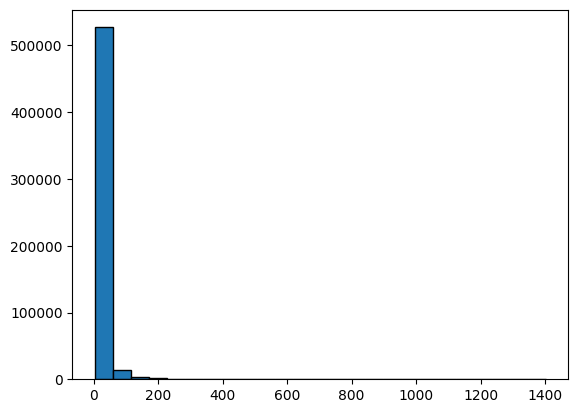

In [ ]:
# Normalizing
sc.pp.normalize_total(data, target_sum=1e4)
tmp = plt.hist(data.X.data, bins=25, edgecolor='black')

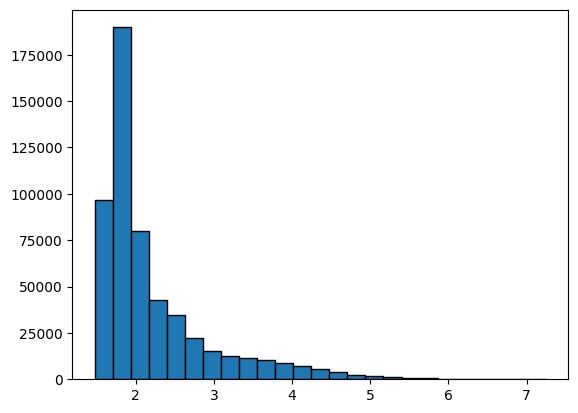

In [ ]:
# Logarithmize the data
sc.pp.log1p(data)
tmp = plt.hist(data.X.data, bins=25, edgecolor='black')

In [ ]:
data.X[0:10, 0:10].todense()

matrix([[0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 2.181034 , 0.       , 0.       , 2.181034 ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 1.6714084, 0.       ,
         0.       , 0.       , 1.6714084, 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.

### Feature Engineering

Out of the 11,074 genes we have left after filtering, many are housekeeping genes. They don't help us to distinguish Tcell from B cell.



In [ ]:
sc.pp.highly_variable_genes(data, n_top_genes=2000)
data.var

,gene_ids,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
LINC00115,ENSG00000225880,6,False,6,0.007317,99.268293,6.0,False,0.037486,1.551491,-0.888911
NOC2L,ENSG00000188976,90,False,90,0.119512,89.024390,98.0,False,0.465135,1.787452,-0.423146
HES4,ENSG00000188290,6,False,6,0.007317,99.268293,6.0,False,0.039242,1.776255,-0.096500
ISG15,ENSG00000187608,290,False,290,0.631707,64.634146,518.0,False,1.369844,2.661378,0.260364
C1orf159,ENSG00000131591,6,False,6,0.007317,99.268293,6.0,False,0.030493,1.506677,-1.046906
...,...,...,...,...,...,...,...,...,...,...,...
MT-CYB,ENSG00000198727,761,True,761,3.957317,7.195122,3245.0,False,2.966298,2.497924,-0.369780
AC145212.1,ENSG00000215750,3,False,3,0.003659,99.634146,3.0,False,0.021137,1.723749,-0.281612
AL592183.1,ENSG00000220023,105,False,105,0.147561,87.195122,121.0,False,0.594821,2.000963,-0.397590
PNRC2-1,ENSG00000215700,31,False,31,0.040244,96.219512,33.0,False,0.189030,1.851328,0.168170


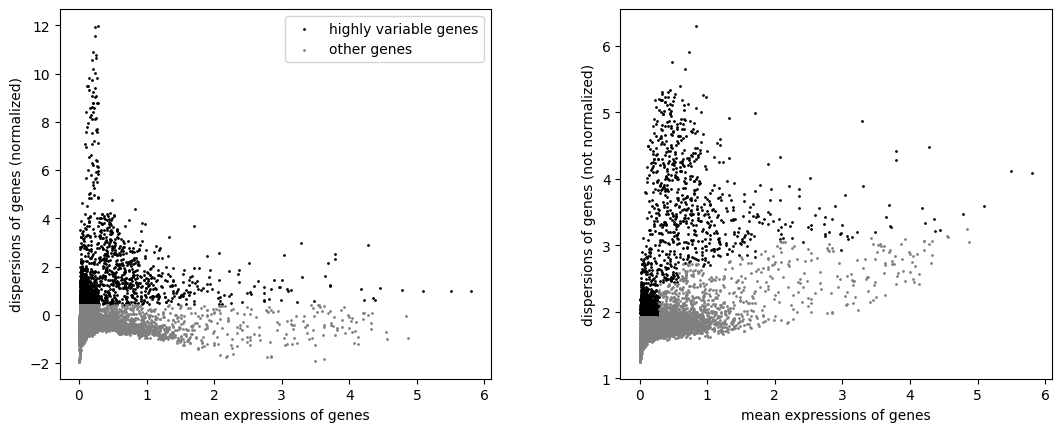

In [ ]:
sc.pl.highly_variable_genes(data)

In [ ]:
sc.tl.pca(data)

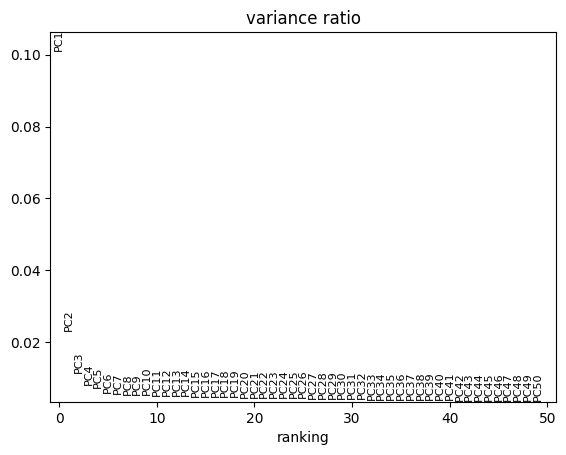

In [ ]:
sc.pl.pca_variance_ratio(data, n_pcs=50, log=False)

We chose 8 PCs to capture the main biological signals while ignoring the 'noise' in the lower-ranked components.

In [ ]:
print(data.obsm['X_pca'][0:5,0:5])
data.obsm['X_pca'].shape

[[ 7.598421    5.9908695  -1.7123815   4.402489    1.1733133 ]
 [ 2.8971975  -5.2337437   0.19599916  0.9668136   0.67657095]
 [-0.24800973 -1.7805772  -3.6745498   1.3505732   1.6054461 ]
 [ 3.3213763  -6.4160395  -3.3647947   2.3944342   1.346772  ]
 [-8.382593    1.242816   -3.3610914   2.5053148  -0.88160396]]


(727, 50)

Clustering

In [ ]:
sc.pp.neighbors(data, n_pcs=8)

In [ ]:
sc.tl.leiden(data, flavor="igraph", resolution=0.3)

In [ ]:
data.obs

,n_genes,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,leiden
AAACCGTGTATGCG-1,522,519,978.0,44.989775,55.828221,67.382413,98.057260,12.0,1.226994,0
AAACGCTGGTTCTT-1,790,787,2257.0,46.787771,61.896323,72.972973,87.284005,70.0,3.101462,1
AAACGCTGTAGCCA-1,533,530,1273.0,51.060487,63.000786,74.076984,97.643362,15.0,1.178319,2
AAAGAGACGGACTT-1,458,455,1149.0,51.958225,65.100087,77.806789,100.000000,27.0,2.349869,2
AAAGTTTGATCACG-1,446,440,1264.0,53.560127,70.174051,81.012658,100.000000,44.0,3.481013,3
...,...,...,...,...,...,...,...,...,...,...
TTTCAGTGGAAGGC-1,692,687,1776.0,47.635135,61.373874,72.578829,89.470721,27.0,1.520270,1
TTTCAGTGTCACGA-1,700,698,1632.0,39.828431,55.882353,69.485294,87.867647,56.0,3.431373,3
TTTCAGTGTGCAGT-1,637,633,1318.0,39.908953,53.945372,67.147193,89.908953,25.0,1.896813,3
TTTCTACTTCCTCG-1,622,620,1682.0,45.838288,61.712247,75.029727,92.865636,37.0,2.199762,3


In [ ]:
sc.set_figure_params(dpi=100, facecolor="white", figsize=(8,8))

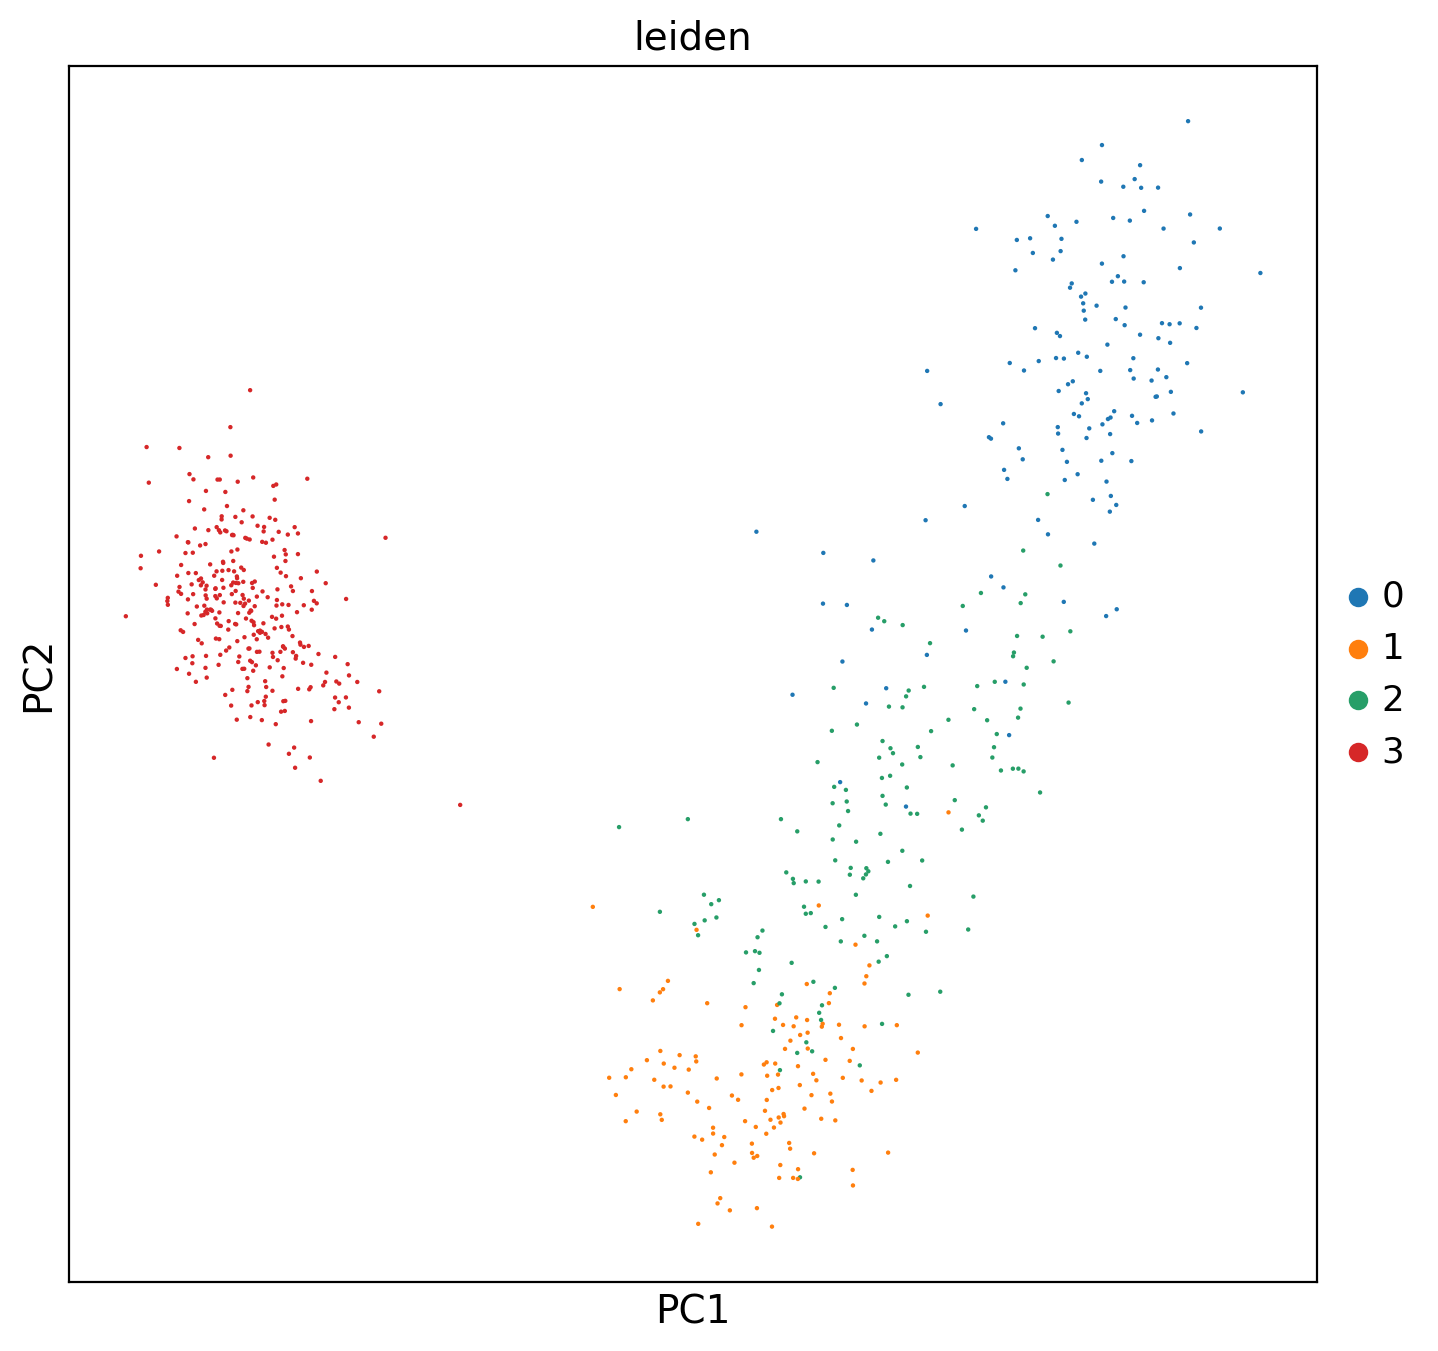

In [ ]:
sc.pl.pca(data, color = "leiden", size=10)

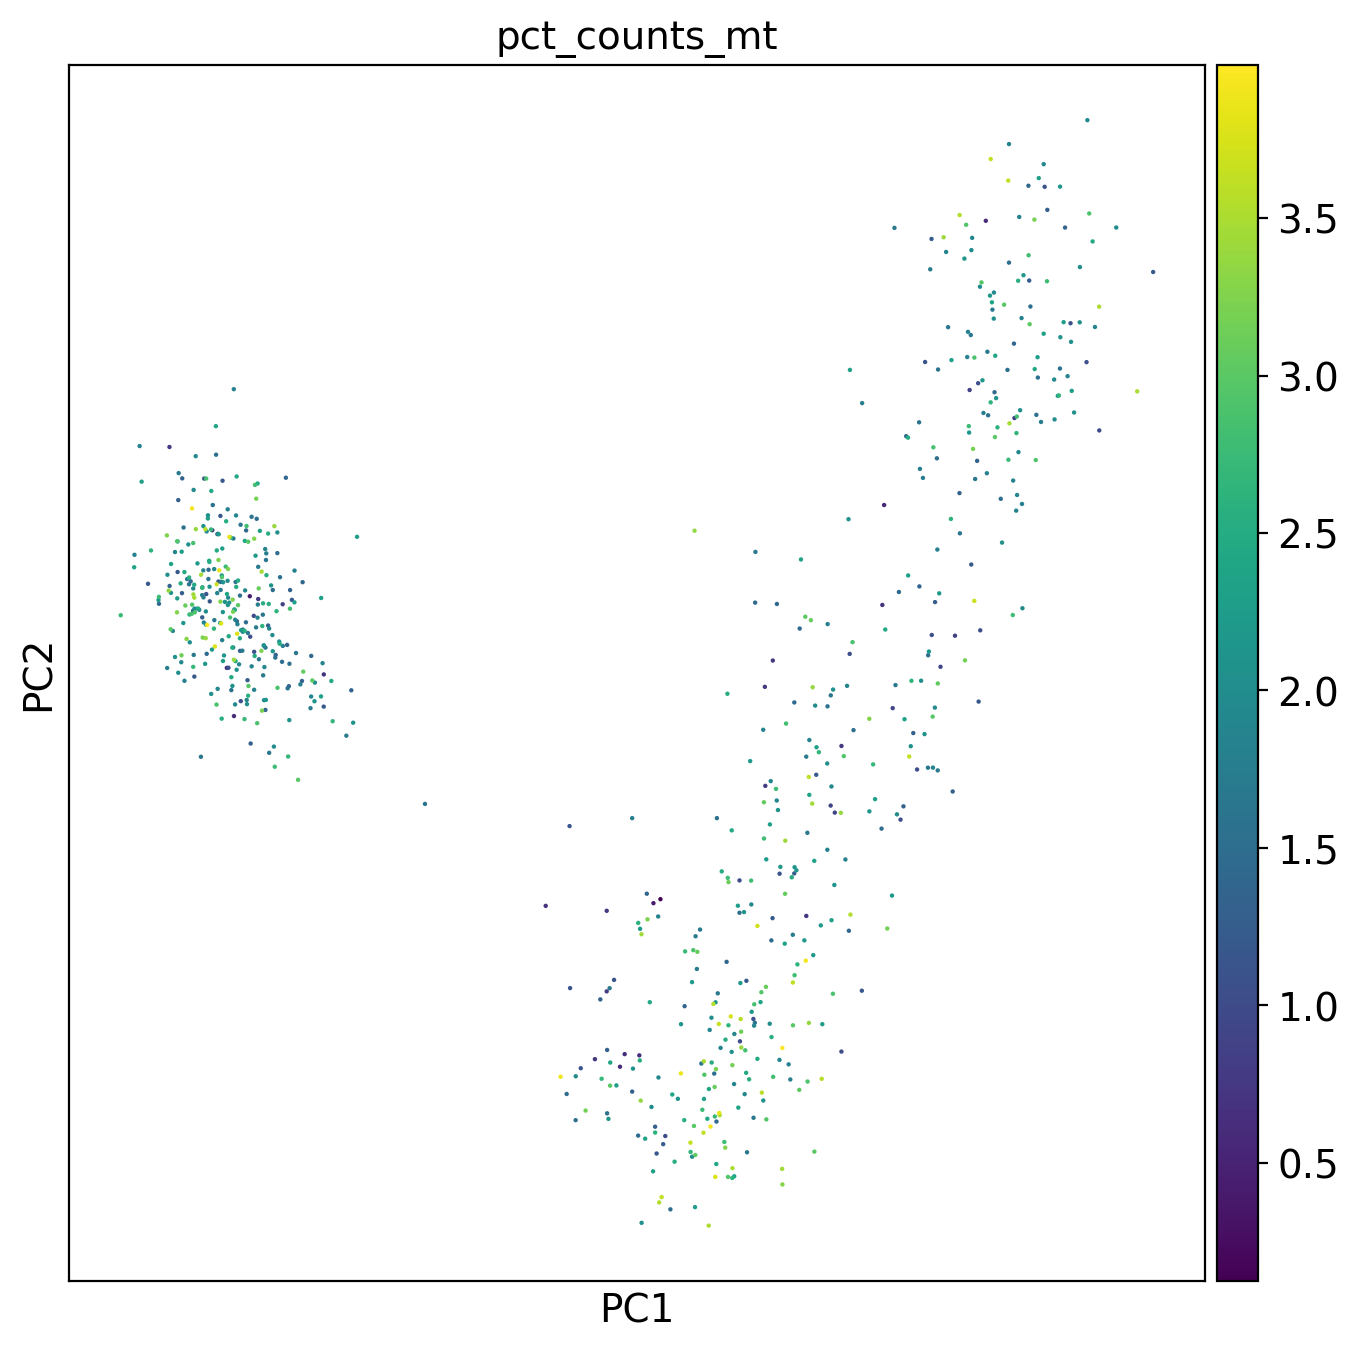

In [ ]:
sc.pl.pca(data, color = "pct_counts_mt", size=10)

If one specific cluster was bright yellow (high MT%), it would suggest that cluster isn't a real cell type, but actually a group of dying cells.

None of the clusters are defined solely by 'stress' or 'death' signals.

In [ ]:
import random
random.seed(148)

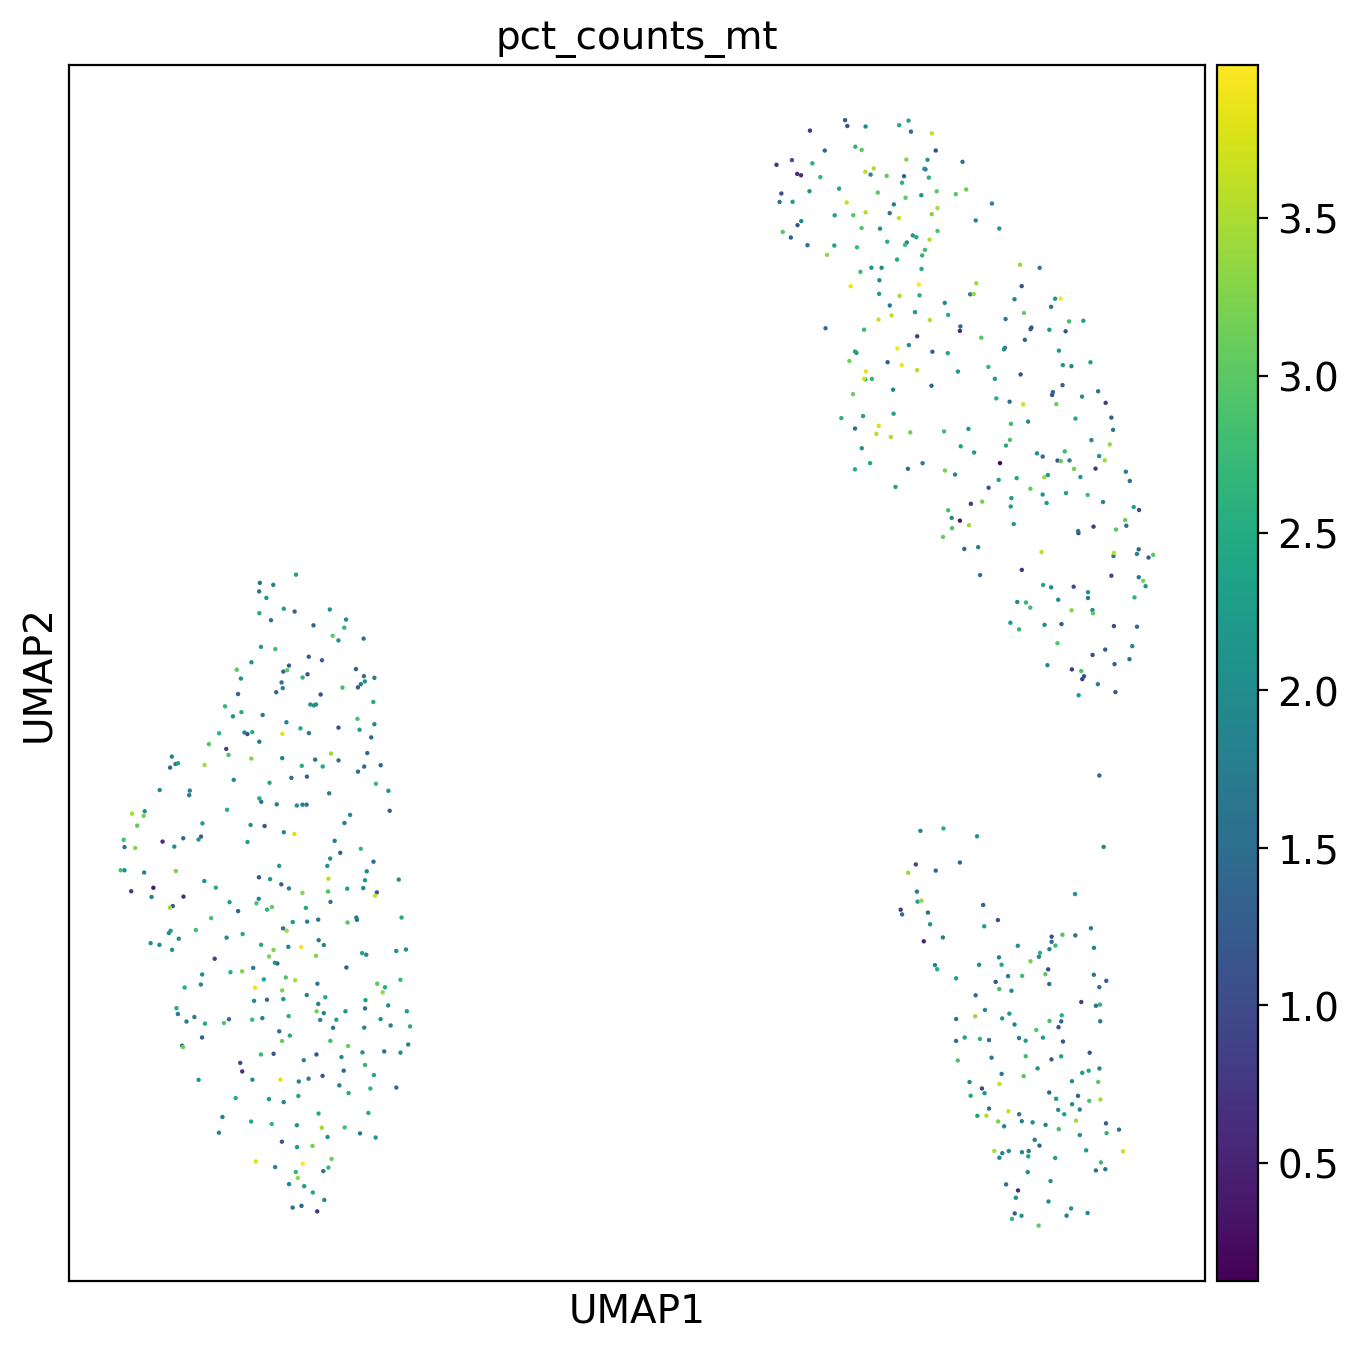

In [ ]:
sc.tl.umap(data)
sc.pl.umap(data, color="pct_counts_mt", size=10)

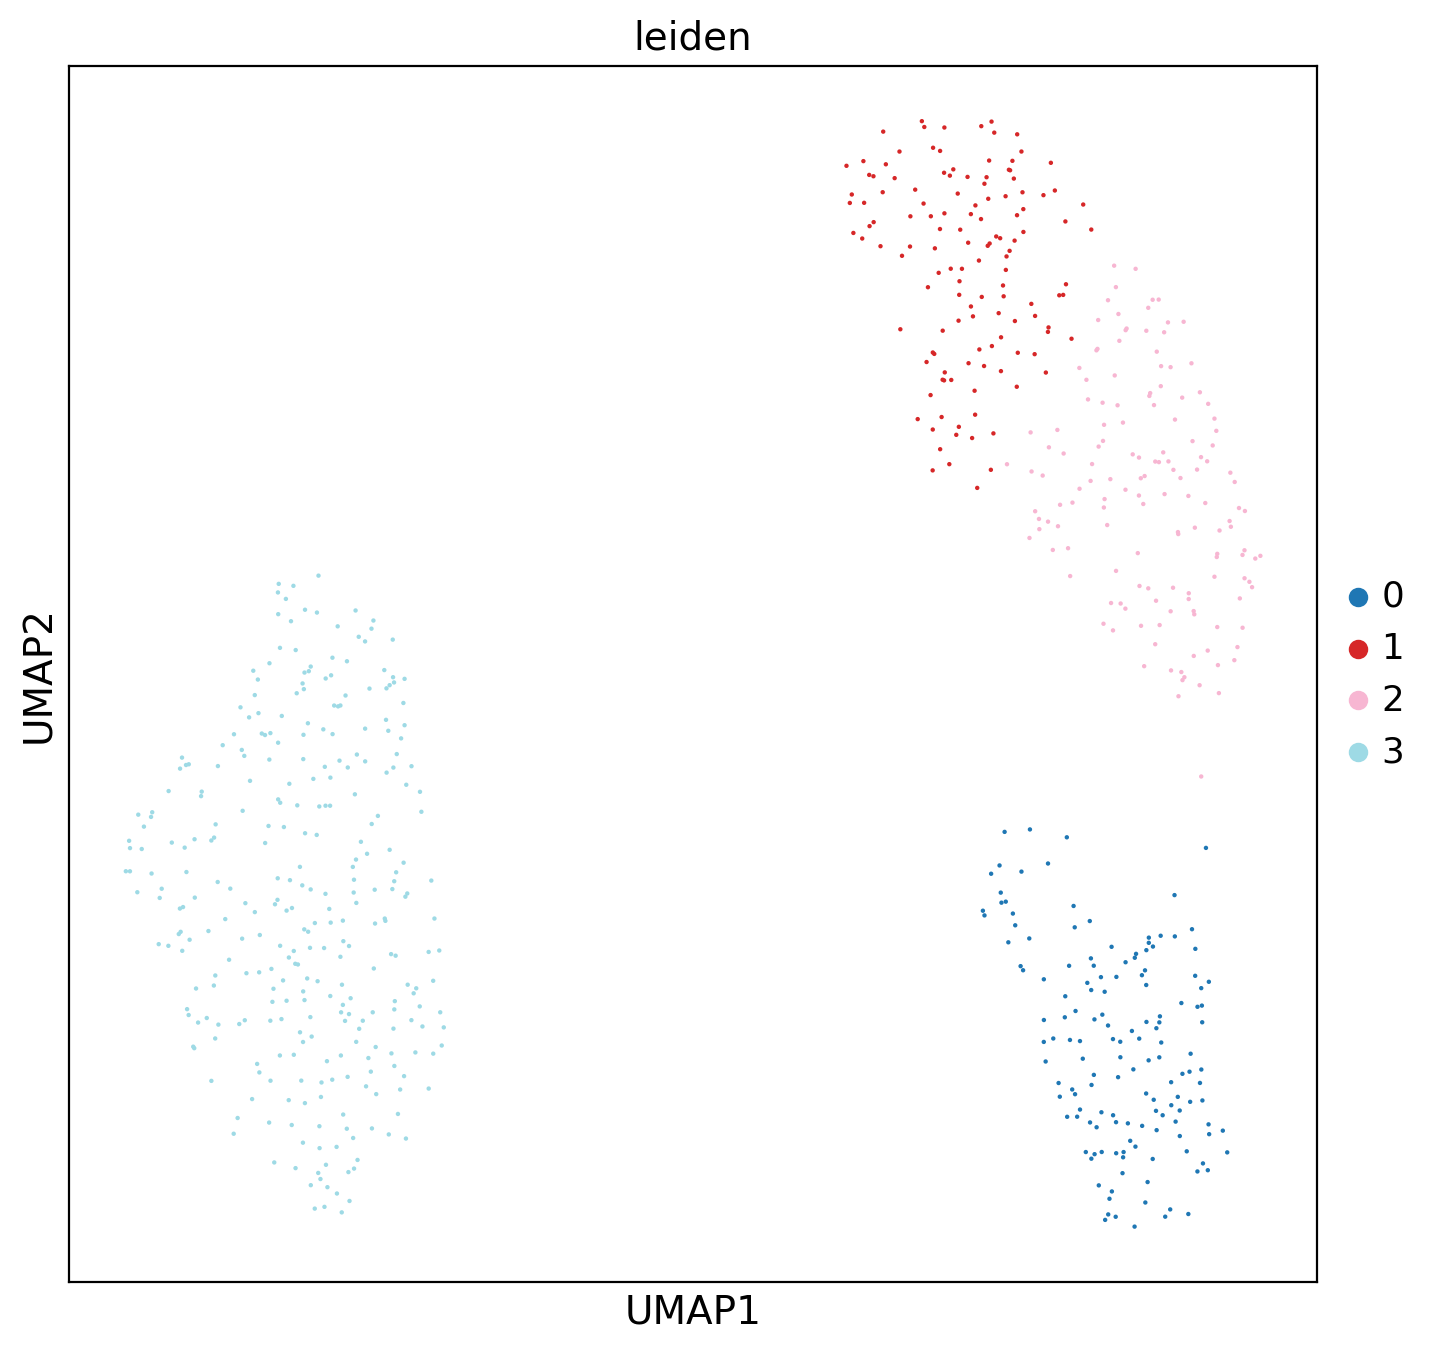

In [ ]:
sc.pl.umap(data, color = "leiden", size=10, palette='tab20')

## Cell type identification

In [ ]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

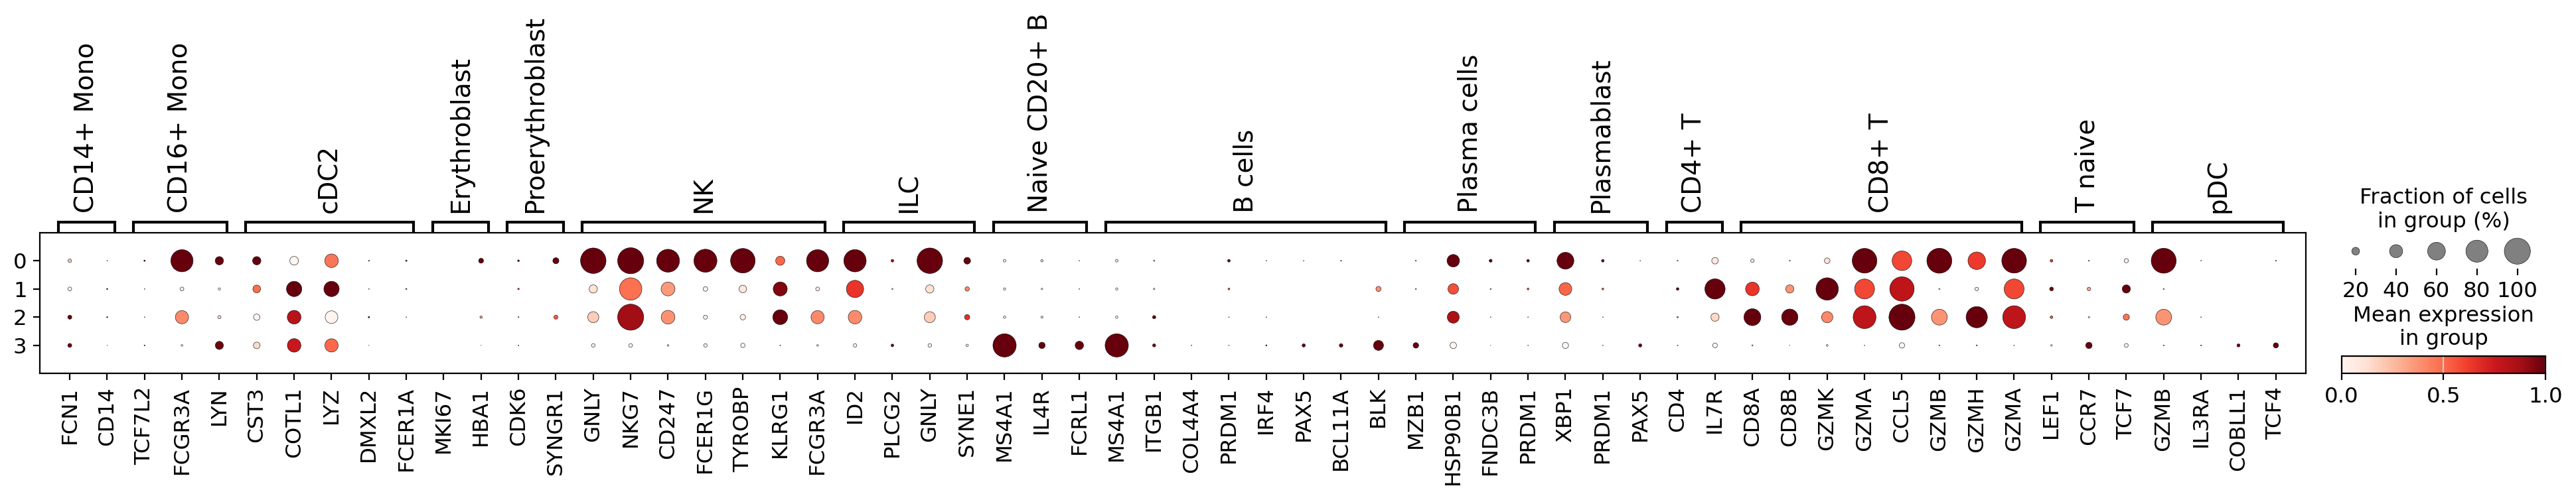

In [ ]:
filtered_marker_genes = {}
# Ensure existing_genes contains standard Python strings
existing_genes = set(str(g) for g in data.var_names)

for cell_type, genes in marker_genes.items():
    # Ensure genes being checked are also standard Python strings
    filtered_genes = [str(gene) for gene in genes if str(gene) in existing_genes]
    if filtered_genes:
        filtered_marker_genes[cell_type] = filtered_genes

sc.pl.dotplot(data, filtered_marker_genes, groupby="leiden", standard_scale="var")

The DotPlot shows which clusters express specific marker genes.

### 2. Identify cell types

We know that these cells must be PBMC. What are the markers identifying different PBMC subgroups?

 Markers | Cell Type
 ---|---
 IL7R | CD4 T cells
 CD14, LYZ | CD14+ Monocytes
 MS4A1 |	B cells
 CD8A |	CD8 T cells
 GNLY, NKG7 | 	NK cells
 FCGR3A, MS4A7 |	FCGR3A+ Monocytes
 FCER1A, CST3 |	Dendritic Cells
 PPBP |	Megakaryocytes

Try to identify the cell type of each cluster using the master above


- **Cluster 0:** Expresses NK markers (GNLY, NKG7).
- **Cluster 1:** Expresses CD8+ T cell markers (CD8A).
- **Cluster 2:** Expresses CD4+ T cell markers (IL7R).
- **Cluster 3:** Expresses B cell markers (MS4A1).

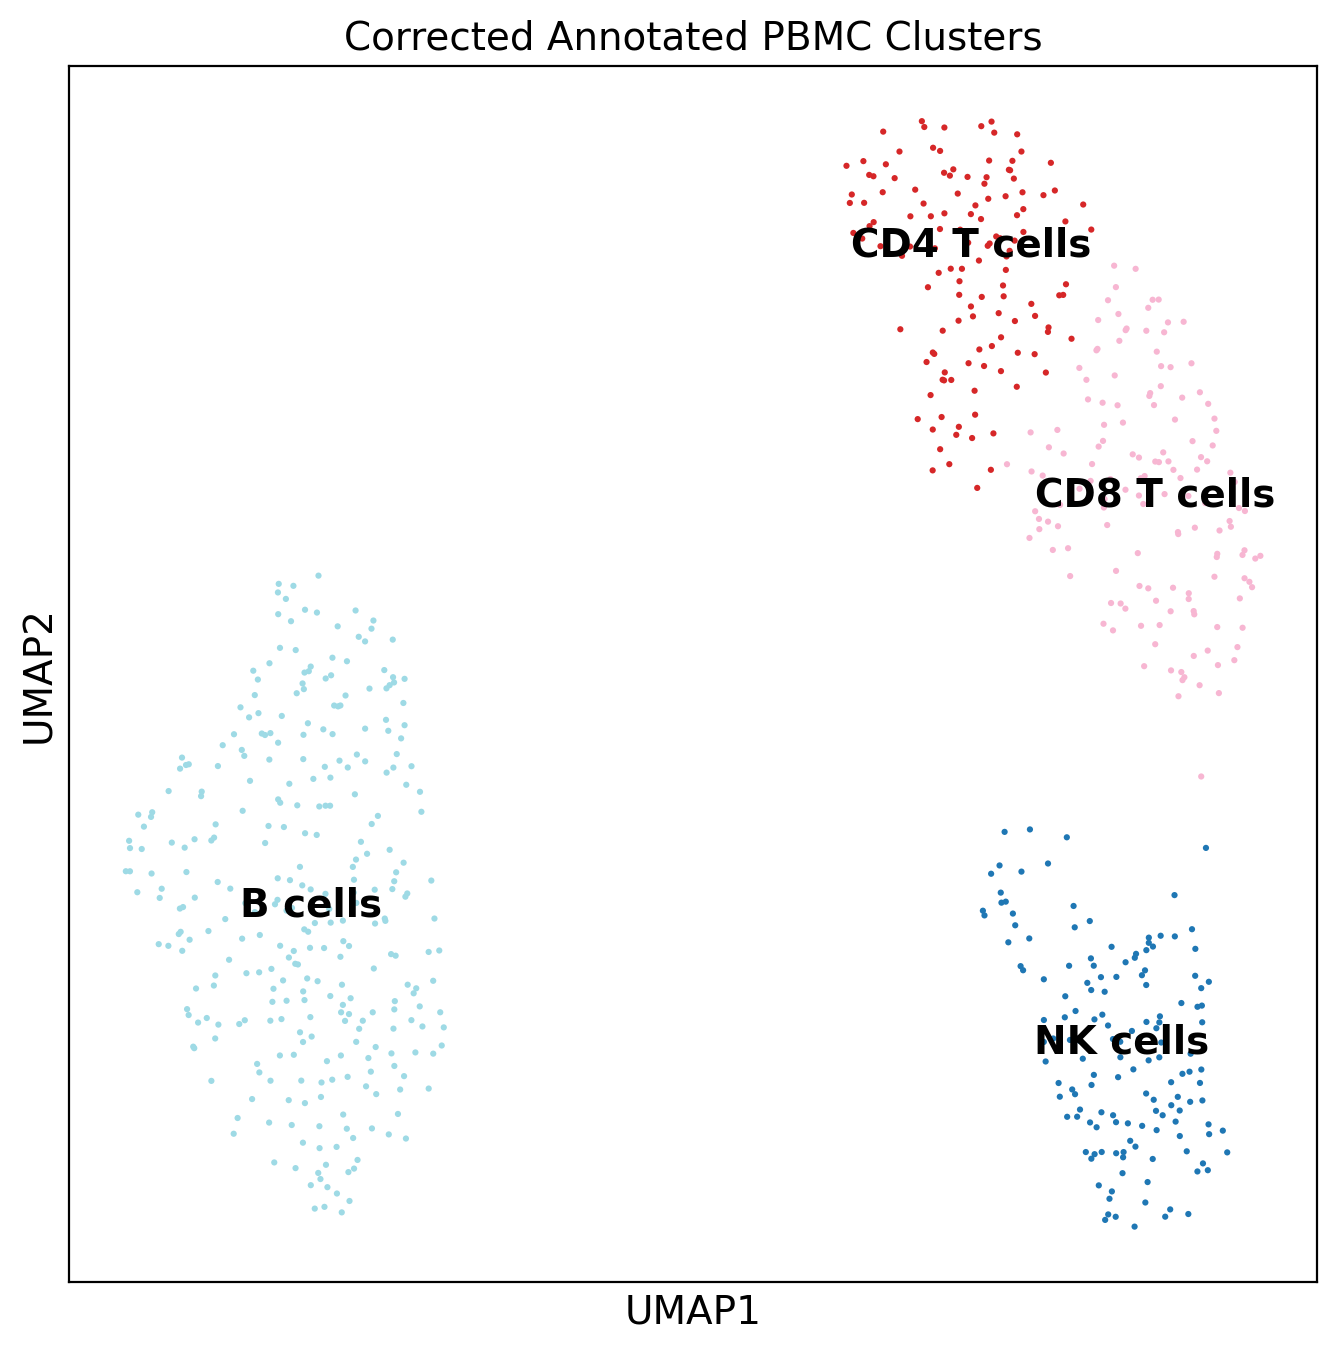

In [ ]:
new_cluster_names = [
    'NK cells',
    'CD4 T cells',
    'CD8 T cells',
    'B cells'
]
data.rename_categories('leiden', new_cluster_names)

# Visualize the corrected annotated clusters
sc.pl.umap(data, color='leiden', legend_loc='on data', title='Corrected Annotated PBMC Clusters', size=20)

### 3. Marker genes

Use the functions *sc.tl.rank_genes_groups* and *sc.get.rank_genes_groups_df* to identify the genes that are differentially expressed in each cluster versus the others

Are these *marker genes* consistent with the cell type you assigned to the cluster?


- The Score (y-axis) represents how much more likely a gene is to be expressed in that cluster compared to all other clusters combined.
- All the cluster (except for CD8 T Cells) seem to be in order to what was expected
- The key to identifying a CD8 T cell is the presence of CD8A. If they have lower scores than a general cytotoxic marker like NKG7, their presence distinguishes them from CD4 T cells and B cells.

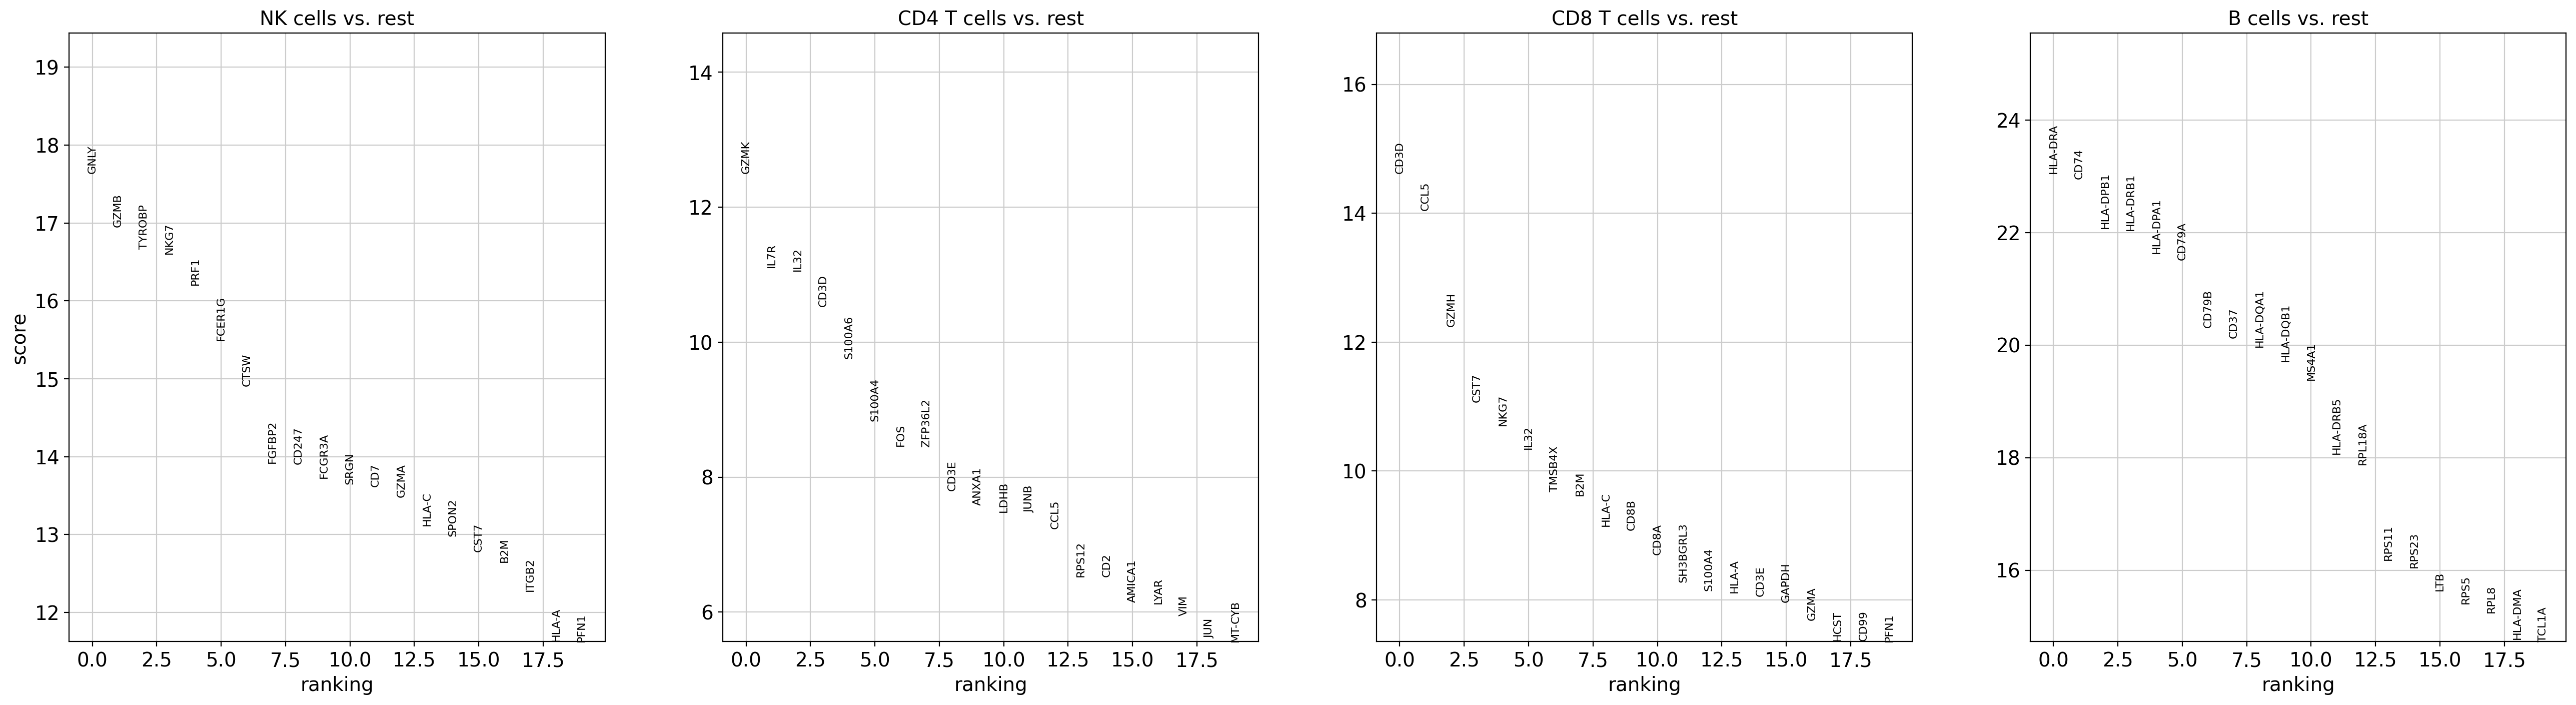

In [ ]:
sc.tl.rank_genes_groups(data, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(data, n_genes=20, sharey=False)

In [ ]:
result_df = sc.get.rank_genes_groups_df(data, group=None)
result_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,NK cells,GNLY,17.632324,7.167556,1.391273e-69,1.540696e-65
1,NK cells,GZMB,16.946852,6.281747,2.030421e-64,1.124244e-60
2,NK cells,TYROBP,16.663183,5.593344,2.427511e-62,8.960753e-59
3,NK cells,NKG7,16.599264,4.750985,7.054954e-62,1.953164e-58
4,NK cells,PRF1,16.203850,4.839864,4.736632e-59,1.049069e-55
...,...,...,...,...,...,...
44291,B cells,CTSW,-19.201256,-6.385683,3.612471e-82,2.500282e-79
44292,B cells,CCL5,-19.367872,-6.457597,1.440894e-83,1.063764e-80
44293,B cells,S100A4,-19.739183,-4.205215,9.937105e-87,9.170292e-84
44294,B cells,B2M,-20.737808,-1.246373,1.579634e-95,2.186608e-92


In [ ]:
# Summarize the top 5 markers for each cluster to make the conclusion easier
top_markers = result_df.groupby('group').head(10)
display(top_markers[['group', 'names', 'scores', 'logfoldchanges', 'pvals_adj']])

,group,names,scores,logfoldchanges,pvals_adj
0,NK cells,GNLY,17.632324,7.167556,1.540696e-65
1,NK cells,GZMB,16.946852,6.281747,1.124244e-60
2,NK cells,TYROBP,16.663183,5.593344,8.960753e-59
3,NK cells,NKG7,16.599264,4.750985,1.953164e-58
4,NK cells,PRF1,16.203850,4.839864,1.049069e-55
5,NK cells,FCER1G,15.487299,5.858213,6.686804e-51
6,NK cells,CTSW,14.902553,3.547185,4.391216e-47
7,NK cells,FGFBP2,13.916440,4.764347,3.716142e-41
8,NK cells,CD247,13.901672,3.973790,4.282768e-41
9,NK cells,FCGR3A,13.720055,4.563884,5.016339e-40


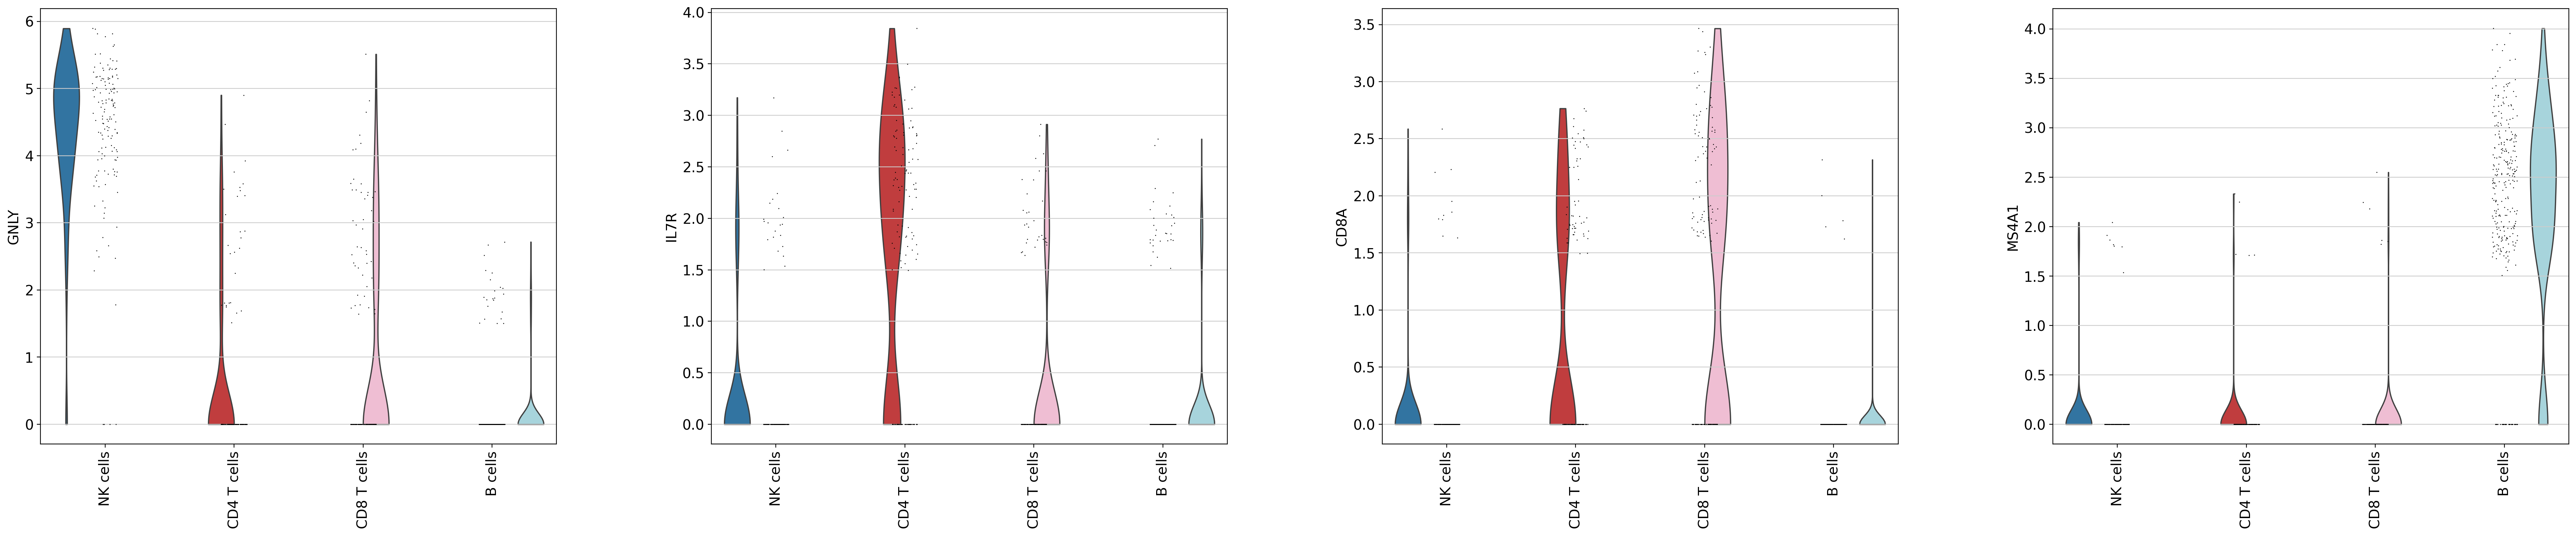

In [ ]:
sc.pl.violin(data, ['GNLY', 'IL7R', 'CD8A', 'MS4A1'], groupby='leiden', rotation=90)

## Final Conclusion

Based on the single-cell transcriptomic analysis of this PBMC dataset, we identified four distinct cell populations:

1. **NK Cells (Cluster 0)**
2. **CD4 T Cells (Cluster 1)**
3. **CD8 T Cells (Cluster 2)**
4. **B Cells (Cluster 3)**